
# Phase 1 : Exploration des données (EDA)

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore")

In [17]:
# Charger les données depuis le fichier csv ou lien
filepath = 'insurance.csv'
df = pd.read_csv(filepath)

# Aperçu rapide des données
print("Aperçu des données :")
print(df.head())
print("\nInformations générales :")
print(df.info())

Aperçu des données :
   age     sex   bmi  children smoker     region  expenses
0   19  female  27.9         0    yes  southwest  16884.92
1   18    male  33.8         1     no  southeast   1725.55
2   28    male  33.0         3     no  southeast   4449.46
3   33    male  22.7         0     no  northwest  21984.47
4   32    male  28.9         0     no  northwest   3866.86

Informations générales :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None


**1. Statistiques descriptives :**


Statistiques descriptives :
                age   sex          bmi     children smoker     region  \
count   1338.000000  1338  1338.000000  1338.000000   1338       1338   
unique          NaN     2          NaN          NaN      2          4   
top             NaN  male          NaN          NaN     no  southeast   
freq            NaN   676          NaN          NaN   1064        364   
mean      39.207025   NaN    30.665471     1.094918    NaN        NaN   
std       14.049960   NaN     6.098382     1.205493    NaN        NaN   
min       18.000000   NaN    16.000000     0.000000    NaN        NaN   
25%       27.000000   NaN    26.300000     0.000000    NaN        NaN   
50%       39.000000   NaN    30.400000     1.000000    NaN        NaN   
75%       51.000000   NaN    34.700000     2.000000    NaN        NaN   
max       64.000000   NaN    53.100000     5.000000    NaN        NaN   

            expenses  
count    1338.000000  
unique           NaN  
top              NaN  
fr

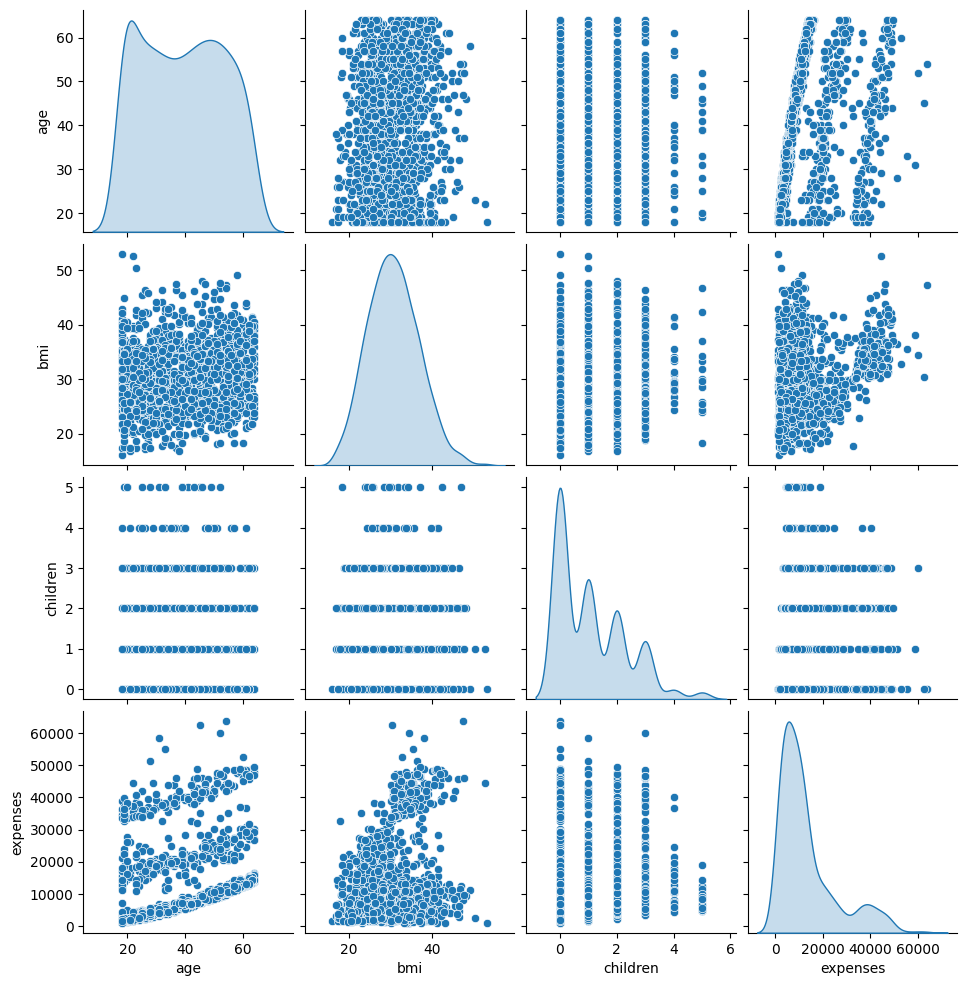

In [18]:
print("\nStatistiques descriptives :")
print(df.describe(include='all'))

print("Informations sur le Dataset:")
print(df.info())

# Visualiser les relations entre variables
sns.pairplot(df, diag_kind="kde")
plt.show()

**Analyse des données**

Nombre d'entrées : 1 338 lignes.

Colonnes disponibles : 7

age, sex, bmi, children, smoker, region, charges.

Aperçu des colonnes :

- age (int) : Âge des individus.
- sex (object) : Sexe (male ou female).
- bmi (float) : Indice de masse corporelle (IMC).
- children (int) : Nombre d'enfants à charge.
- smoker (object) : Statut fumeur (yes ou no).
- region (object) : Région géographique (northeast, southeast, southwest, northwest).
- charges (float) : Montant des frais médicaux (en dollars).

**2. Corrélation**

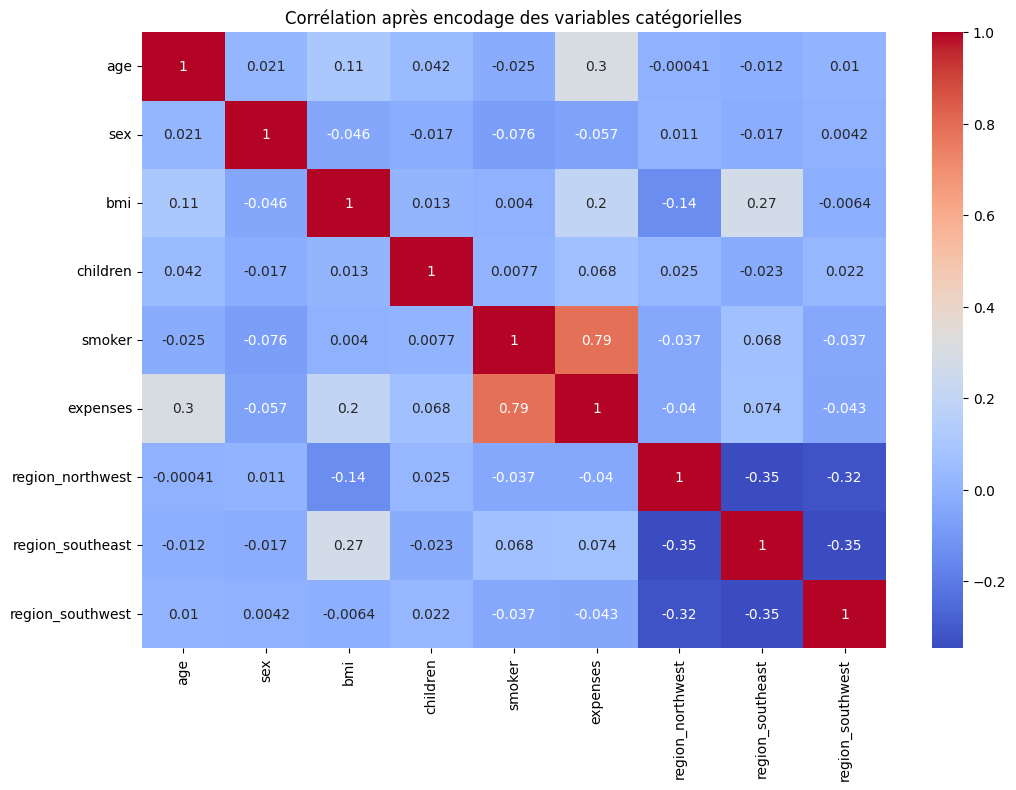

In [19]:
# Encodage des variables catégorielles
df_encoded = df.copy()
df_encoded["sex"] = df_encoded["sex"].map({"male": 0, "female": 1})
df_encoded["smoker"] = df_encoded["smoker"].map({"no": 0, "yes": 1})
df_encoded = pd.get_dummies(df_encoded, columns=["region"], drop_first=True)

# Visualisation de la matrice de corrélation
plt.figure(figsize=(12, 8))
sns.heatmap(df_encoded.corr(), annot=True, cmap="coolwarm")
plt.title("Corrélation après encodage des variables catégorielles")
plt.show()

**Vérification des valeurs manquantes**

In [20]:
# vérifier les valeurs manquantes
missing_values = df.isnull().sum()

# Résumé statistique des données numériques
stats_summary = df.describe()

# Affichage des résultats
missing_values, stats_summary

(age         0
 sex         0
 bmi         0
 children    0
 smoker      0
 region      0
 expenses    0
 dtype: int64,
                age          bmi     children      expenses
 count  1338.000000  1338.000000  1338.000000   1338.000000
 mean     39.207025    30.665471     1.094918  13270.422414
 std      14.049960     6.098382     1.205493  12110.011240
 min      18.000000    16.000000     0.000000   1121.870000
 25%      27.000000    26.300000     0.000000   4740.287500
 50%      39.000000    30.400000     1.000000   9382.030000
 75%      51.000000    34.700000     2.000000  16639.915000
 max      64.000000    53.100000     5.000000  63770.430000)

# Phase 2 : Prétraitement des données

In [21]:
# Séparer les variables explicatives (X) et la cible (y)
X = df.drop("expenses", axis=1)
y = df["expenses"]

# Variables catégorielles et numériques
categorical_features = X.select_dtypes(include=["object"]).columns
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns

# Transformation
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(), categorical_features)
    ])

# Split des données en entraînement et test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Phase 3 : Modélisation, entraînement et optimisation des modèles de régression

In [22]:
# Entraîner un modèle de régression linéaire
linear_pipeline = Pipeline(steps=[("preprocessor", preprocessor), 
                                  ("model", LinearRegression())])

linear_pipeline.fit(X_train, y_train)
y_pred_linear = linear_pipeline.predict(X_test)

# Évaluation du modèle linéaire
print("Régression Linéaire")
print("MAE :", mean_absolute_error(y_test, y_pred_linear))
print("MSE :", mean_squared_error(y_test, y_pred_linear))
print("R2 :", r2_score(y_test, y_pred_linear))

Régression Linéaire
MAE : 4179.999365671642
MSE : 33610916.987676494
R2 : 0.7835027946393588


**Entraînement de Modèles Avancés**

In [23]:
# Dictionnaire des modèles
models = {
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "Random Forest": RandomForestRegressor(random_state=42)
}

# Entraîner et évaluer chaque modèle
for name, model in models.items():
    pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    print(f"{name}")
    print("MAE :", mean_absolute_error(y_test, y_pred))
    print("MSE :", mean_squared_error(y_test, y_pred))
    print("R2 :", r2_score(y_test, y_pred))
    print("-" * 30)

Ridge
MAE : 4187.274297456975
MSE : 33623384.93692299
R2 : 0.7834224851324972
------------------------------
Lasso
MAE : 4182.448965262213
MSE : 33609002.115553685
R2 : 0.7835151288599147
------------------------------
Random Forest
MAE : 2562.995361492538
MSE : 21313509.94979983
R2 : 0.8627137920024697
------------------------------


# Phase 4 et 5 : Évaluation et Interprétation

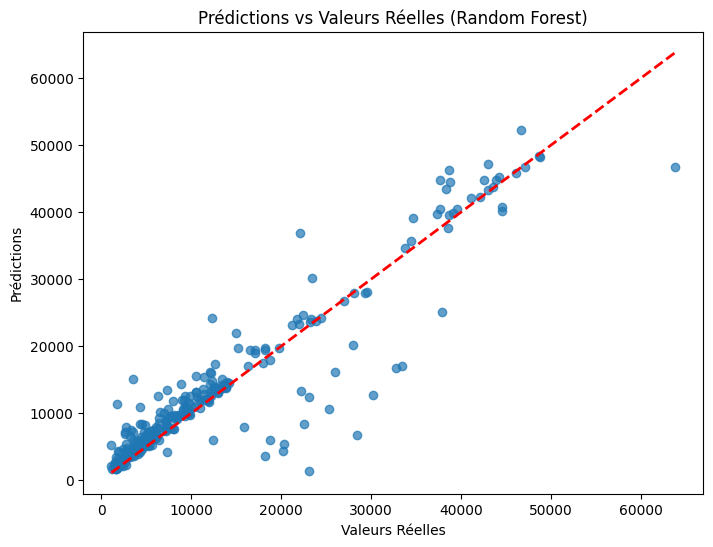

In [24]:
# Comparer les prédictions avec les valeurs réelles pour le modèle Random Forest
final_model = RandomForestRegressor(random_state=42)
final_pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("model", final_model)])
final_pipeline.fit(X_train, y_train)
y_pred_rf = final_pipeline.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
plt.title("Prédictions vs Valeurs Réelles (Random Forest)")
plt.xlabel("Valeurs Réelles")
plt.ylabel("Prédictions")
plt.show()

In [ ]:
import joblib

# Sauvegarder le modèle final
joblib.dump(final_pipeline, "insurance_model.pkl")
print("Modèle exporté sous le nom 'insurance_model.pkl'")